# Özel (Custom) Transformer

In [1]:
import pandas as pd
import seaborn as sns

👉 Bu veri setini kullanacağız:

In [2]:
data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_data.csv")
data.head()

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,days_until_delivery
0,RJ,SP,1825,53,10,40,9
1,RJ,SP,700,65,18,28,9
2,RJ,SP,1825,53,10,40,11
3,RJ,SP,1825,53,10,40,12
4,RJ,SP,1825,53,10,40,14


- Veri setindeki her bir gözlem, bir ürünün bir `seller_state`’ten bir `customer_state`’e teslim edilmesini temsil eder.  
- Diğer sütunlar, her bir ürünün paketleme özelliklerini açıklar.

🎯 Hedef, sipariş ile teslimat arasındaki gün sayısıdır.

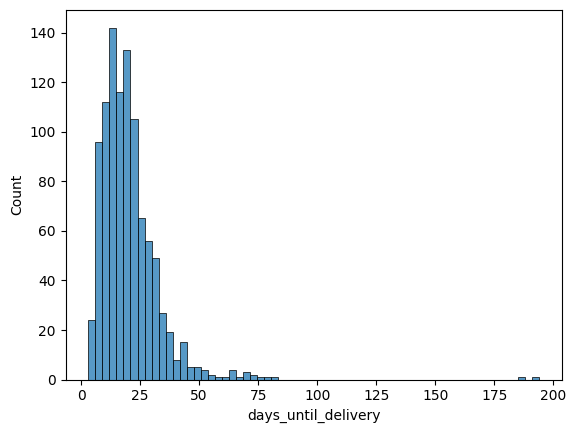

In [3]:
sns.histplot(data.days_until_delivery);

## 1. Pipeline

👉 `pipe` adlı bir scikit-learn pipeline oluşturun:

- Boyut feature’larından (`dimensions`) bir `volume` feature’ı türetin
- Eğitim için orijinal ürün boyut feature’larını koruyun
- Tüm sayısal feature’ları ölçekleyin
- Kategorik feature’ları encode edin
- Varsayılan ayarlarla bir `Ridge` regresyon estimator’ı ekleyin

**Not:** Bu challenge için holdout yöntemi yok sayılacaktır; yani `train_test_split` kullanmanıza gerek yoktur!

<details><summary><strong>İpuçları</strong></summary>

- Ön işlenmiş feature matrisinizi oluşturmanın birçok yolu vardır (`ColumnTransformer` ve/veya `FeatureUnion` kullanarak). 
    
- Dönüştürülmüş feature matrisiniz garip görünüyorsa, bunun nedeni `OneHotEncoder(sparse_output=True)` varsayılan davranışıyla matrisin "sparse" olarak saklanması olabilir. Bunu tekrar dense bir matrise çevirmek için `.todense()` kullanın.

- Varsayılan NumPy array çıktısı yerine sütun adlarıyla birlikte bir Pandas DataFrame çıktısı almak için, final pipeline’ınızda `.set_output(transform='pandas')` kullanın. (Bunu her bir transformer üzerinde tek tek ayarlamanıza gerek yoktur. Pipeline üzerinde ayarlarsanız, bunu alt aşamalara da aktarır.)

</details>

<br>

<details><summary><strong>Daha fazla ipucu: adım adım yönlendirme</strong> (yalnızca takılırsanız açın)</summary>

Pipeline’ı oluşturmanın en kolay yolu budur.

1. Uzunluk, genişlik ve yükseklik verildiğinde hacmi hesaplayan bir python `function` oluşturun.
2. Aşağıdakilerden oluşan bir hacim hesaplayıcı pipeline oluşturun:
   1. Python `function`’ınızı kullanan bir `FunctionTransformer`.
   1. Ardından bir scaler
3. `ColumnTransformer` kullanarak tam bir preprocessor oluşturun:
   - Orijinal sayısal feature’lar için bir scaler.
   - Kategorik feature’lar için bir encoder.
   - Uzunluk, genişlik ve yükseklik feature’ları için hacim hesaplayıcı pipeline’ınız.
4. Son olarak, tam preprocessor’ınızı ve ardından `Ridge` modelini içeren bir pipeline oluşturun.

</details>

In [11]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, TransformerMixin

class VolumeTransformer(BaseEstimator, TransformerMixin):
    """Boyut sütunlarından hacim türetir, orijinal sütunları korur."""

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_ = pd.DataFrame(X).copy()
        X_['volume'] = (X_['product_length_cm']
                        * X_['product_width_cm']
                        * X_['product_height_cm'])
        return X_

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([])
        return np.array(list(input_features) + ['volume'])

X = data.drop(columns=['days_until_delivery'])
y = data['days_until_delivery']

categorical_cols = ['customer_state', 'seller_state']
numerical_cols   = [c for c in X.columns if c not in categorical_cols]


preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('volume', VolumeTransformer()),
            ('scaler', StandardScaler()),
        ]), numerical_cols),
       ('cat_customer', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['customer_state']),
('cat_seller',   OneHotEncoder(drop=None,    sparse_output=False, handle_unknown='ignore'), ['seller_state']),
    ],
    remainder='drop'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

X_transformed = pipe[:-1].fit_transform(X)
print(f"Dönüştürülmüş matris şekli: {X_transformed.shape}")
print(f"Beklenen: (1000, 31)")

Dönüştürülmüş matris şekli: (1000, 31)
Beklenen: (1000, 31)


#### 🧪  pipe'ını test et

In [12]:
from nbresult import ChallengeResult

pipe_test = pipe

assert pipe_test.fit(X, y)

result = ChallengeResult(
    'pipe',
    shape = pipe_test[:-1].fit_transform(X).shape
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D1-S-Data-Custom-Transformer/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 1 item

test_pipe.py::TestPipe::test_pipe_not_crashing PASSED                    [100%]

============================== 1 passed in 0.83s ===============================


💯 You can commit your code:

git add tests/pipe.pickle

git commit -m 'Completed pipe step'

git push origin master



## 2. Train ve Predict

👇 `data`’nın tüm eğitim veri setiniz olduğunu varsayalım.

- Bu veri seti üzerinde pipeline’ınızı `cross_validate` edin (❗️düşük $R^2$ skorları beklenmektedir)
- Şimdi de yeni bir sipariş aldığınızı varsayın: `new_data`  
  Teslimat süresini tahmin edin ve sonucu `prediction` adlı değişkende saklayın

In [18]:
new_data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_new_order.csv")
new_data

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,RJ,SP,1825,53,10,40


In [22]:
import warnings
from sklearn.model_selection import cross_validate, KFold

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cv_results = cross_validate(
        pipe, X, y,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring='r2'
    )

print(f"R² skorları: {cv_results['test_score'].round(4)}")
print(f"Ortalama R²: {cv_results['test_score'].mean():.4f}")

pipe.fit(X, y)
prediction = pipe.predict(new_data)
print(f"\nYeni sipariş teslimat süresi tahmini: {prediction[0]:.2f} gün")

R² skorları: [0.1424 0.1723 0.1754 0.0889 0.1062]
Ortalama R²: 0.1371

Yeni sipariş teslimat süresi tahmini: 20.69 gün


In [23]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())



============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D1-S-Data-Custom-Transformer/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 1 item

test_prediction.py::TestPrediction::test_prediction PASSED               [100%]

============================== 1 passed in 0.78s ===============================


💯 You can commit your code:

git add tests/prediction.pickle

git commit -m 'Completed prediction step'

git push origin master



🏁 Tebrikler. Not defterinizi eklemeyi, kaydetmeyi ve göndermeyi unutmayın.